# Mistral Embeddings

Embeddings are vector representations of text that capture the semantic meaning of paragraphs through their position in a high-dimensional vector space. The Mistral Embeddings API offers cutting-edge, state-of-the-art embeddings for text, which can be used for many NLP tasks. In this guide, we will cover the fundamentals of the Mistral Embeddings API, including how to measure the distance between text embeddings, and explore its main use cases: clustering and classification.

## Cookbook
We will dig into the following:
- **Mistral Embeddings API**: Basics of how to call and use our embeddings service.
  - **Basics:** Get started by getting embeddings using our SDK.
  - **Distance Measures**: How to compute the distance between embeddings.
  - **Paraphrase Detection**: Use distance-based similarity to detect paraphrases.
  - **Mistral Embeddings API with Batching**: Leverage basic batching functionality available out of the box.
- **t-SNE Embeddings Visualization**: Visualize and understand how embeddings represent text.
- **Classification**: Learn how to use embeddings for classification tasks.
  - **ML Classification Models**: Using embeddings as input, efficiently create ML models for classification.
  - **Clustering**: Explore clustering and how it can be used for classification.
  - **Compare Solutions**: See side by side how, by leveraging embeddings, you can easily create classification systems more capable and cost-effective than SOTA general-purpose models.

## Mistral Embeddings API

### Basics
To generate text embeddings using Mistral's embeddings API, we can make a request to the API endpoint and specify the embedding model `mistral-embed`, along with providing a list of input text. The API will then return the corresponding embeddings as numerical vectors, which can be used for further analysis or processing in NLP applications.

In [ ]:
!pip install mistralai seaborn numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.7 MB/s eta 0:00:00


In [ ]:
from mistralai.client import Mistral

api_key = "API_KEY"
model = "mistral-embed"

client = Mistral(api_key=api_key)

embeddings_batch_response = client.embeddings.create(
    model=model,
    inputs=["Embed this sentence.", "As well as this one."],
)


The output is a EmbeddingResponse object with the embeddings and the token usage information.

```
Data(id='eb4c2c739780415bb3af4e47580318cc', object='list', data=[EmbeddingObject(object='embedding', embedding=[-0.0165863037109375,...], index=0), Data(object='embedding', embedding=[-0.0234222412109375,...], index=1)], model='mistral-embed', usage=EmbeddingResponseUsage(prompt_tokens=15, total_tokens=15, completion_tokens=0))

```
Let’s take a look of the length of the first embedding:


In [ ]:
len(embeddings_batch_response.data[0].embedding)

1024

It returns 1024, which means that our embedding dimension is 1024. The `mistral-embed` model generates embedding vectors of dimension 1024 for each text string, regardless of the text length.  It’s worth noting that while higher dimensional embeddings can better capture text information and improve the performance of NLP tasks, they may require more computational resources for hosting and inference, and may result in increased latency and memory usage for storing and processing these embeddings. This trade-off between performance and computational resources should be considered when designing NLP systems that rely on text embeddings.

### Distance measures

In the realm of text embeddings, texts with similar meanings or context tend to be located in closer proximity to each other within this space, as measured by the distance between their vectors. This is due to the fact that the model has learned to group semantically related texts together during the training process.

Let’s take a look at a simple example. To simplify working with text embeddings, we can wrap the embedding API in this function:


In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

def get_text_embedding(inputs):
    embeddings_batch_response = client.embeddings.create(
        model=model,
        inputs=inputs
    )
    return embeddings_batch_response.data[0].embedding

Suppose we have two sentences: one about cats and the other about books.  We want to find how similar each sentence is to the reference sentence "Books are mirrors: You only see in them what you already have inside you". We can see that the distance between the reference sentence embeddings and the book sentence embeddings is smaller than the distance between the reference sentence embeddings and the cat sentence embeddings.


In [ ]:
sentences = [
    "A home without a cat — and a well-fed, well-petted and properly revered cat — may be a perfect home, perhaps, but how can it prove title?",
    "I think books are like people, in the sense that they’ll turn up in your life when you most need them"
]
embeddings = [get_text_embedding([t]) for t in sentences]

In [ ]:
reference_sentence = "Books are mirrors: You only see in them what you already have inside you"
reference_embedding = get_text_embedding([reference_sentence])

In [ ]:
for t, e in zip(sentences, embeddings):
    distance = euclidean_distances([e], [reference_embedding])
    print(t, distance)

A home without a cat — and a well-fed, well-petted and properly revered cat — may be a perfect home, perhaps, but how can it prove title? [[0.80147394]]
I think books are like people, in the sense that they’ll turn up in your life when you most need them [[0.58114868]]


In our example above, we used the Euclidean distance to measure the distance between embedding vectors (note that since Mistral embeddings are norm 1, cosine similarity, dot product or Euclidean distance are all equivalent).

### Paraphrase detection

Another potential use case is paraphrase detection. In this simple example, we have a list of three sentences, and we would like to find out if any of the two sentences are paraphrases of each other. If the distance between two sentence embeddings is small, it suggests that the two sentences are semantically similar and could be potential paraphrases.

Result suggests that the first two sentences are semantically similar and could be potential paraphrases, whereas the third sentence is more different. This is just a super simple example. But this approach can be extended to more complex situations in real-world applications, such as detecting paraphrases in social media posts, news articles, or customer reviews.



In [ ]:
sentences = [
    'Have a safe happy Memorial Day weekend everyone',
    'To all our friends at Whatsit Productions Films enjoy a safe happy Memorial Day weekend',
    'Where can I find the best cheese?'
]

In [ ]:
sentence_embeddings = [get_text_embedding([t]) for t in sentences]

In [ ]:
import itertools

sentence_embeddings_pairs = list(itertools.combinations(sentence_embeddings, 2))
sentence_pairs = list(itertools.combinations(sentences, 2))

In [ ]:
for s, e in zip(sentence_pairs, sentence_embeddings_pairs):
    print(s, euclidean_distances([e[0]], [e[1]]))

('Have a safe happy Memorial Day weekend everyone', 'To all our friends at Whatsit Productions Films enjoy a safe happy Memorial Day weekend') [[0.54411384]]
('Have a safe happy Memorial Day weekend everyone', 'Where can I find the best cheese?') [[0.92601883]]
('To all our friends at Whatsit Productions Films enjoy a safe happy Memorial Day weekend', 'Where can I find the best cheese?') [[0.91241492]]


### Batch processing

The Mistral Embeddings API is designed to process text in batches for improved efficiency and speed. In this example, we will demonstrate this by loading the Symptom2Disease dataset from [Kaggle](https://www.kaggle.com/datasets/niyarrbarman/symptom2disease), which contains 1200 rows with two columns: "label" and "text". The "label" column indicates the disease category, while the "text" column describes the symptoms associated with that disease.

We wrote a function `get_embeddings_by_chunks` that splits data into chunks and then sends each chunk to the Mistral embedding API to get the embeddings. Then we saved the embeddings as a new column in the dataframe. Note that the Mistral Embeddings API will provide auto-chunking in the future, so that users don’t need to manually split the data into chunks before sending it to the API.


In [ ]:
import pandas as pd

# Download the dataset
URL = "https://raw.githubusercontent.com/mistralai/cookbook/main/data/Symptom2Disease.csv"
df = pd.read_csv(URL, index_col=0)

# Remove full-row duplicates, keeping the first occurrence
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Removed:     {before - after} duplicate rows")

Rows before: 1200
Rows after:  1153
Removed:     47 duplicate rows


In [ ]:
def get_embeddings_by_chunks(data, chunk_size):
    chunks = [data[x : x + chunk_size] for x in range(0, len(data), chunk_size)]
    embeddings_response = [
        client.embeddings.create(model=model, inputs=c) for c in chunks
    ]
    return [d.embedding for e in embeddings_response for d in e.data]

In [ ]:
df['embeddings'] = get_embeddings_by_chunks(df['text'].tolist(), 50)

In [ ]:
df.head()

,label,text,embeddings
0,Psoriasis,I have been experiencing a skin rash on my arm...,"[-0.0361328125, 0.041351318359375, 0.073364257..."
1,Psoriasis,"My skin has been peeling, especially on my kne...","[-0.053466796875, 0.05242919921875, 0.07366943..."
2,Psoriasis,I have been experiencing joint pain in my fing...,"[-0.0347900390625, 0.0262908935546875, 0.03585..."
3,Psoriasis,"There is a silver like dusting on my skin, esp...","[-0.0361328125, 0.057220458984375, 0.053009033..."
4,Psoriasis,"My nails have small dents or pits in them, and...","[-0.0246429443359375, 0.0394287109375, 0.04776..."


## t-SNE embeddings visualization

We mentioned previously that our embeddings have 1024 dimensions, which makes them impossible to visualize directly. Thus, in order to visualize our embeddings, we can use a dimensionality reduction technique such as t-SNE to project our embeddings into a lower-dimensional space that is easier to visualize.

In this example, we transform our embeddings to 2 dimensions and create a 2D scatter plot showing the relationships among embeddings of different diseases.


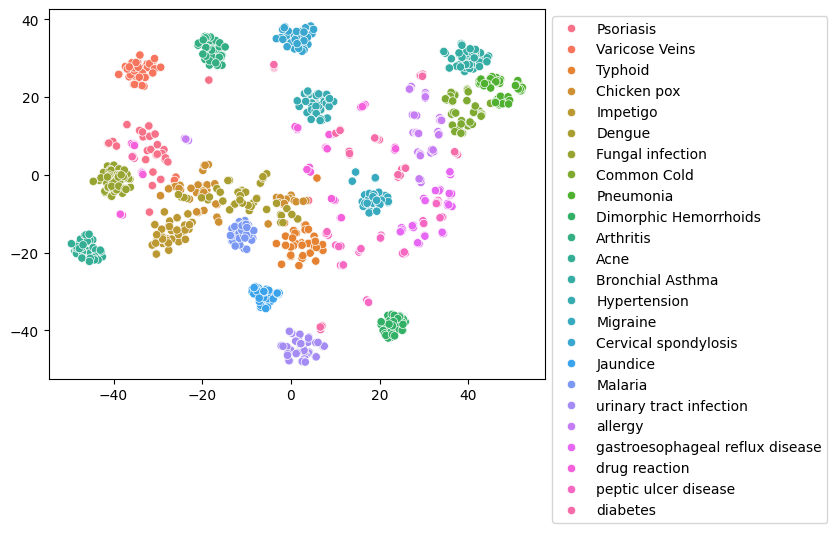

In [ ]:
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np


tsne = TSNE(n_components=2, random_state=0).fit_transform(np.array(df['embeddings'].to_list()))
ax = sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=np.array(df['label'].to_list()))
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))


#### Comparison with fasttext

We can compare it with fastText, a popular open-source embeddings model. However, when examining the t-SNE embeddings plot, we notice that fastText embeddings fail to create clear separations between data points with matching labels.


In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.1.0-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.1.0-py3-none-any.whl (319 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp313-cp313-linux_x86_64.whl size=4792504 sha256=d9f3a6254d6e74229dd5cbe57b121d2b7b8ca40ad2d63338ff98f10c815a84a2
  Stored in directory: /root/.cache/pip/wheels/59/06/3f/c95dbba0df6e58ba6ed18220c1aea1e96042802139df3674ef
Successfully built fasttext


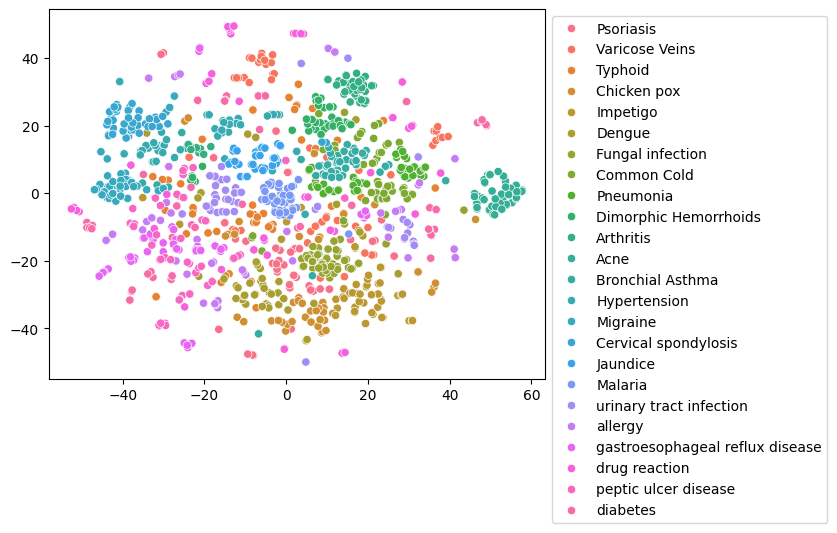

In [ ]:
# @title Compute Fasttext Visualisation

import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')  # English
ft = fasttext.load_model('cc.en.300.bin')

df['fasttext_embeddings'] = df['text'].apply(lambda x: ft.get_word_vector(x).tolist())

tsne = TSNE(n_components=2, random_state=0).fit_transform(np.array(df['fasttext_embeddings'].to_list()))
ax = sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=np.array(df['label'].to_list()))
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))

## Classification

### ML Classification Models
Text embeddings can be used as input features in machine learning models, such as classification and clustering. In this example, we use a classification model to predict the disease labels from the embeddings of disease description text.



In [ ]:
# Create a train / test split

from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(df['embeddings'], df["label"], test_size=0.2, random_state=42)

In [ ]:
# Normalize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x = scaler.fit_transform(train_x.to_list())
test_x = scaler.transform(test_x.to_list())

In [ ]:
# Train a classifier and compute the test accuracy

from sklearn.linear_model import LogisticRegression

# For a real problem, C should be properly cross validated and the confusion matrix analyzed
clf = LogisticRegression(random_state=0, C=1.0, max_iter=500).fit(train_x, train_y.to_list())

# you can also try the sag algorithm:
# clf = LogisticRegression(random_state=0, C=1.0, max_iter=1000, solver='sag').fit(train_x, train_y)

mistral_classifier_precision = 100*np.mean(clf.predict(test_x) == test_y.to_list())

print(f"Precision: {mistral_classifier_precision:.2f}%")

Precision: 98.27%


In [ ]:
# Classify a single example
text = "I've been experiencing frequent headaches and vision problems."
clf.predict([get_text_embedding([text])])

array(['Migraine'], dtype='<U31')

#### Comparison with fasttext
Additionally, let’s take a look at the performance using fastText embeddings in this classification task. It appears that the classification model achieves better performance with Mistral embedding models as compared to using fastText embeddings.


In [ ]:
# @title Compute Fasttext LogisticRegression Results

# Create a train / test split
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(df['fasttext_embeddings'], df["label"], test_size=0.2, random_state=42)
# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x.to_list())
test_x = scaler.transform(test_x.to_list())
# Train a classifier and compute the test accuracy
from sklearn.linear_model import LogisticRegression
# For a real problem, C should be properly cross validated and the confusion matrix analyzed
clf = LogisticRegression(random_state=0, C=1.0, max_iter=500).fit(train_x, train_y.to_list())
# you can also try the sag algorithm:
# clf = LogisticRegression(random_state=0, C=1.0, max_iter=1000, solver='sag').fit(train_x, train_y)
fasttext_classifier_precision = 100*np.mean(clf.predict(test_x) == test_y.to_list())
print(f"Precision: {fasttext_classifier_precision:.2f}%")

Precision: 89.61%


**A Logistic Regression classifier using Mistral Embed achieves a precision of 98%**, compared to 89% with FastText.

### Clustering

What if we don't have disease labels? One approach to gain insights from the data is through clustering. Clustering is an unsupervised machine learning technique that groups similar data points together based on their similarity with respect to certain features. In the context of text embeddings, we can use the distance between each embedding as a measure of similarity, and group together data points with embeddings that are close to each other in the high-dimensional space.

Since we already know there are 24 clusters, let's use the K-means clustering with 24 clusters. Then we can inspect a few examples and verify whether the examples in a single cluster are similar to one another. For example, take a look at the first three rows of cluster 23. We can see that they look very similar in terms of symptoms.



In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=24, max_iter=1000)
model.fit(df['embeddings'].to_list())
df["cluster"] = model.labels_

In [ ]:
print(*df[df.cluster==23].text.head(3), sep='\n')

I have frequent belching and burping. I have chest pain that often radiates to the back of my neck, jaw and arm. I get a feeling of tightness and pressure on my chest
I get frequent heartburn and indigestion, especially eating spicy foods or fatty foods. I get chest pain that gets worse when I lie down or bend over. I also often have chest pain
I have a feeling of food or acid backing up into my throat. I chest pain which gets worse if I lie down. I get frequent heartburn or indigestion, after eating food and vomit it out


We can **use this clustering approach to predict and classify** without training a classifier or using logistic regression. For this, we fit KMeans with 24 clusters on the training set, then assign each test point the label of its nearest cluster centroid.

In [ ]:
import numpy as np

# Train / test split
train_x, test_x, train_y, test_y = train_test_split(
    df['embeddings'], df["label"], test_size=0.2, random_state=42
)

# Normalize features (fit on train only)
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x.to_list())
test_x  = scaler.transform(test_x.to_list())
train_y = np.array(train_y.to_list())
test_y  = np.array(test_y.to_list())

# Fit KMeans on the training embeddings only
n_clusters = 24
model = KMeans(n_clusters=n_clusters, max_iter=1000, random_state=0).fit(train_x)

# Give each cluster the label of the training points it contains
cluster_label = {}
for c in range(n_clusters):
    mask = model.labels_ == c
    if mask.any():
        vals, counts = np.unique(train_y[mask], return_counts=True)
        cluster_label[c] = vals[counts.argmax()]
    else:
        cluster_label[c] = None

# Predict: nearest centroid -> that cluster's label
pred_y = np.array([cluster_label[c] for c in model.predict(test_x)])

mistral_cluster_precision = 100*np.mean(pred_y == test_y)
print(f"Precision: {mistral_cluster_precision:.2f}%")

Precision: 78.35%


### Comparison with FastText
As before, we can compare the performance of our clustering approach using Mistral embeddings with FastText embeddings.

In [ ]:
# @title Compute Fasttext Clustering Results

# Train / test split
train_x, test_x, train_y, test_y = train_test_split(
    df['fasttext_embeddings'], df["label"], test_size=0.2, random_state=42
)

# Normalize features (fit on train only)
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x.to_list())
test_x  = scaler.transform(test_x.to_list())
train_y = np.array(train_y.to_list())
test_y  = np.array(test_y.to_list())

# Fit KMeans on the training embeddings only
n_clusters = 24
model = KMeans(n_clusters=n_clusters, max_iter=1000, random_state=0).fit(train_x)

# Give each cluster thelabel of the training points it contains
cluster_label = {}
for c in range(n_clusters):
    mask = model.labels_ == c
    if mask.any():
        vals, counts = np.unique(train_y[mask], return_counts=True)
        cluster_label[c] = vals[counts.argmax()]
    else:
        cluster_label[c] = None

# Predict: nearest centroid -> that cluster's majority label
pred_y = np.array([cluster_label[c] for c in model.predict(test_x)])

fasttext_cluster_precision = 100*np.mean(pred_y == test_y)
print(f"Precision: {fasttext_cluster_precision:.2f}%")

Precision: 42.86%


**A clustering classifier using Mistral Embed achieves a precision of 78%**, compared to 42% with FastText.

# Compare Solutions
You have learned how to leverage embeddings for classification and how they work. **We will now compare their performance against an LLM-powered classifier.** When developing solutions for your use cases, one of the simplest approaches is to use a general-purpose model to classify by providing a prompt and, sometimes, structured outputs.

**We strongly recommend that you evaluate your use case and explore cost-effective solutions.** Below, we will be evaluating two very different models: GLM 5.2 with reasoning effort set to Max, a powerful third-party model with strong reasoning capabilities, and Mistral Small 4 with no reasoning, a fast and cost-effective model.

In [ ]:
from enum import Enum
from pydantic import BaseModel

class Disease(str, Enum):
    PSORIASIS = "Psoriasis"
    VARICOSE_VEINS = "Varicose Veins"
    TYPHOID = "Typhoid"
    CHICKEN_POX = "Chicken pox"
    IMPETIGO = "Impetigo"
    DENGUE = "Dengue"
    FUNGAL_INFECTION = "Fungal infection"
    COMMON_COLD = "Common Cold"
    PNEUMONIA = "Pneumonia"
    DIMORPHIC_HEMORRHOIDS = "Dimorphic Hemorrhoids"
    ARTHRITIS = "Arthritis"
    ACNE = "Acne"
    BRONCHIAL_ASTHMA = "Bronchial Asthma"
    HYPERTENSION = "Hypertension"
    MIGRAINE = "Migraine"
    CERVICAL_SPONDYLOSIS = "Cervical spondylosis"
    JAUNDICE = "Jaundice"
    MALARIA = "Malaria"
    URINARY_TRACT_INFECTION = "urinary tract infection"
    ALLERGY = "allergy"
    GASTROESOPHAGEAL_REFLUX_DISEASE = "gastroesophageal reflux disease"
    DRUG_REACTION = "drug reaction"
    PEPTIC_ULCER_DISEASE = "peptic ulcer disease"
    DIABETES = "diabetes"

class Label(BaseModel):
    label: Disease

LABELS = [d.value for d in Disease]

In [ ]:
SYSTEM = """You are a classifier. Given symptoms of diseases, pick the disease label most likely to correspond to it.

# Labels
Select one of the labels provided. Your reply must include it written exactly as provided, preserving the same case (lowercase or uppercase) and spacing.
{}

# Response Format
Reply with the following JSON format:
{{"label": <str>}}
""".format(" - " + "\n - ".join(LABELS))

MODEL = "zai-glm-5-2"

In [ ]:
from tqdm import tqdm
from mistralai.extra import response_format_from_pydantic_model
import time

RETRIES = 5
def classify_reasoning(chunk):
    for i in range(RETRIES):
        try:
            resp = client.chat.complete(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM},
                    {"role": "user", "content": chunk},
                ],
                response_format=response_format_from_pydantic_model(Label),
                reasoning_effort="high"
                #temperature=0
            )
            return Label.model_validate_json(resp.choices[0].message.content[-1].text).label.value
        except Exception as e:
            time.sleep(2*(i+1))
    raise

def predict_reasoning(texts):
    preds = []
    for chunk in tqdm(texts):
        try:
            preds.append(classify_reasoning(chunk))
        except Exception as e:
            print(e)
            preds.append(f"error: {e}")
    return preds

In [ ]:
# Create a train / test split
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

# Loop to classify each test sample
test_preds = predict_reasoning(test_x)

100%|██████████| 231/231 [13:25<00:00,  3.49s/it]


In [ ]:
# Compute precision (multiclass, macro-averaged)
# For a real problem, the confusion matrix should be analyzed and the averaging
# strategy (macro / weighted) chosen based on class balance
import numpy as np
from sklearn.metrics import precision_score

valid = [p for p in test_preds if not p.startswith("error:")]
if len(valid) != len(test_preds):
    print(f"Skipped {len(test_preds) - len(valid)} failed predictions")

glm_llm_prompt = 100 * precision_score(test_y.to_list(), valid, average='macro')
print(f"Precision: {glm_llm_prompt:.2f}%")

Precision: 73.67%


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# @title Compute Mistral Small 4 No-Reasoning

MODEL = "mistral-small-2603"
retries = 5

def classify_non_reasoning(chunk):
    for i in range(retries):
        try:
            resp = client.chat.parse(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM},
                    {"role": "user", "content": chunk},
                ],
                response_format=Label,
                temperature=0
            )
            return resp.choices[0].message.parsed.label.value
        except Exception as e:
            time.sleep(2*(i+1))
    raise

def predict_non_reasoning(texts):
    preds = []
    for chunk in tqdm(texts):
        try:
            preds.append(classify_non_reasoning(chunk))
        except Exception as e:
            preds.append(f"error: {e}")
    return preds

test_preds = predict_non_reasoning(test_x)

valid = [p for p in test_preds if not p.startswith("error:")]
if len(valid) != len(test_preds):
    print(f"Skipped {len(test_preds) - len(valid)} failed predictions")

small_llm_prompt = 100 * precision_score(test_y.to_list(), valid, average='macro')
print(f"Precision: {small_llm_prompt:.2f}%")

100%|██████████| 231/231 [02:09<00:00,  1.78it/s]

Precision: 57.93%


In [ ]:
# @title Random Solution
import random

def predict_random(texts):
    preds = []
    for chunk in tqdm(texts):
        try:
            preds.append(random.choice(LABELS))
        except Exception as e:
            preds.append(f"error: {e}")
    return preds

test_preds = predict_random(test_x)

valid = [p for p in test_preds if not p.startswith("error:")]
if len(valid) != len(test_preds):
    print(f"Skipped {len(test_preds) - len(valid)} failed predictions")

random_precision = 100 * precision_score(test_y.to_list(), valid, average='macro')
print(f"Precision: {random_precision:.2f}%")

100%|██████████| 231/231 [00:00<00:00, 381300.36it/s]

Precision: 4.96%


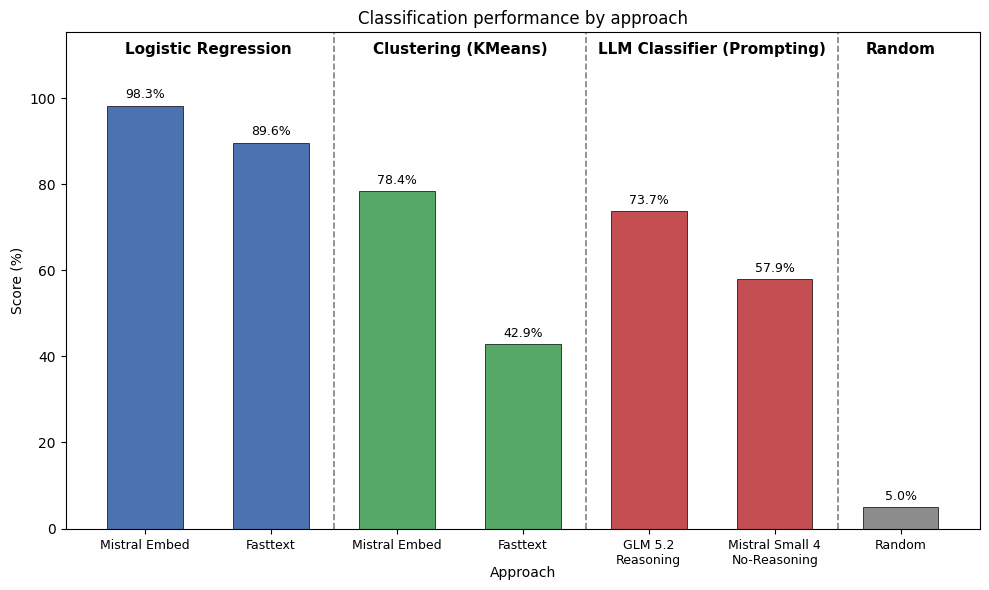

In [ ]:
# @title Plot Classification Performance per Approach
import matplotlib.pyplot as plt
import numpy as np

# --- Gather the scores computed in the previous sections ---
approaches = ["Mistral Embed", "Fasttext", "Mistral Embed", "Fasttext", "GLM 5.2\nReasoning", "Mistral Small 4\nNo-Reasoning", "Random"]
groups     = [
    "Logistic Regression", "Logistic Regression",
    "Clustering (KMeans)", "Clustering (KMeans)",
    "LLM Classifier (Prompting)", "LLM Classifier (Prompting)",
    "Random"
]
scores = [
    mistral_classifier_precision, fasttext_classifier_precision,
    mistral_cluster_precision,    fasttext_cluster_precision,
    glm_llm_prompt, small_llm_prompt,
    random_precision
]

x = np.arange(len(scores))

# Color per group
group_colors = {
    "Logistic Regression": "#4C72B0",
    "Clustering (KMeans)": "#55A868",
    "LLM Classifier (Prompting)": "#C44E52",
    "Random": "#8C8C8C",
}
colors = [group_colors[g] for g in groups]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, scores, color=colors, width=0.6, edgecolor="black", linewidth=0.5)

# Score + approach labels on/under each bar
for bar, s, a in zip(bars, scores, approaches):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{s:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.text(bar.get_x() + bar.get_width() / 2, -2.5, a,
            ha="center", va="top", fontsize=9)

# --- Vertical separators between the three segments ---
ax.axvline(1.5, color="grey", linestyle="--", linewidth=1.2)
ax.axvline(3.5, color="grey", linestyle="--", linewidth=1.2)
ax.axvline(5.5, color="grey", linestyle="--", linewidth=1.2)

# Segment titles above the plot
y_top = max(scores) + 12
ax.text(0.5, y_top, "Logistic Regression", ha="center", fontsize=11, fontweight="bold")
ax.text(2.5, y_top, "Clustering (KMeans)",          ha="center", fontsize=11, fontweight="bold")
ax.text(4.5, y_top, "LLM Classifier (Prompting)",      ha="center", fontsize=11, fontweight="bold")
ax.text(6.0, y_top, "Random",      ha="center", fontsize=11, fontweight="bold")

# Hide the numeric x tick labels (approach names are drawn manually below each bar)
ax.set_xticks(x)
ax.set_xticklabels([''] * len(x))
ax.set_xlabel("Approach", labelpad=20)
ax.set_ylabel("Score (%)")
ax.set_title("Classification performance by approach")
ax.set_ylim(0, y_top + 5)

plt.tight_layout()
plt.show()

Leveraging Mistral embeddings, it's possible to achieve very high performance while reducing cost and latency compared to SOTA general-purpose models. Here we explored simple examples of what ML models and clustering can give you, but you can achieve better results by exploring custom solutions for your use cases.

## Retrieval

Our embedding model excels in retrieval tasks, as it is trained with retrieval in mind. Embeddings are also incredibly helpful in implementing retrieval-augmented generation (RAG) systems, which use retrieved relevant information from a knowledge base to generate responses. At a high-level, we embed a knowledge base, whether it is a local directory, text files, or internal wikis, into text embeddings and store them in a vector database. Then, based on the user's query, we retrieve the most similar embeddings, which represent the relevant information from the knowledge base. Finally, we feed these relevant embeddings to a large language model to generate a response that is tailored to the user's query and context. If you are interested in learning more about how RAG systems work and how to implement a basic RAG, check out our [previous guide](https://github.com/mistralai/cookbook/blob/main/mistral/rag/basic_RAG.ipynb) on this topic.
